In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt


In [69]:
df = pd.read_csv('data/ads.csv')
df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,45-54/unknown,55-64/female,55-64/male,55-64/unknown,65+/female,65+/male,65+/unknown,Unknown/female,Unknown/male,Unknown/unknown
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.02,0.97,1.22,0.01,0.94,0.80,0.01,0.0,0.0,0.0
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,0.02,2.56,5.44,0.06,3.05,3.22,0.04,0.0,0.0,0.0
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.13,19.85,0.25,20.26,12.40,0.25,0.0,0.0,0.0
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.72,19.94,0.25,18.27,10.68,0.25,0.0,0.0,0.0
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,18.72,21.20,0.28,14.66,10.20,0.22,0.0,0.0,0.0


In [3]:
df.columns

Index(['id', 'ad_creation_time', 'ad_delivery_start_time', 'bylines',
       'currency', 'page_id', 'page_name', 'ad_creative_bodies',
       'ad_creative_link_captions', 'ad_creative_link_descriptions',
       'ad_creative_link_titles', 'audience_size_lower', 'impressions_lower',
       'impressions_upper', 'spend_lower', 'spend_upper', 'ad_snapshot_url',
       'language_en', 'language_es', 'language_other', 'platform_fb',
       'platform_ig', 'platform_other', '13-17/female', '13-17/male',
       '13-17/unknown', '18-24/female', '18-24/male', '18-24/unknown',
       '25-34/female', '25-34/male', '25-34/unknown', '35-44/female',
       '35-44/male', '35-44/unknown', '45-54/female', '45-54/male',
       '45-54/unknown', '55-64/female', '55-64/male', '55-64/unknown',
       '65+/female', '65+/male', '65+/unknown', 'Unknown/female',
       'Unknown/male', 'Unknown/unknown'],
      dtype='object')

In [4]:
#TARGET DEMOGRAPHICS

In [5]:
demo_cols = [c for c in df.columns if '/' in c]

# melt
demo_df = (
    df.melt(
        id_vars=['id', 'impressions_lower', 'impressions_upper', 'spend_lower', 'spend_upper'],
        value_vars=demo_cols
    )
)
demo_df[['age_group','gender']] = demo_df['variable'].str.split('/', expand=True)
demo_df = demo_df.drop(columns=['variable'])

demo_df.head()

,id,impressions_lower,impressions_upper,spend_lower,spend_upper,value,age_group,gender
0,1263237120532732,60000,69999.0,100,199.0,0.0,13-17,female
1,2508232389430627,20000,24999.0,0,99.0,0.0,13-17,female
2,156182708989204,60000,69999.0,700,799.0,0.0,13-17,female
3,397644197860634,60000,69999.0,700,799.0,0.0,13-17,female
4,527071631288361,70000,79999.0,700,799.0,0.0,13-17,female


In [13]:
problem_ads = (demo_df.groupby('id')['value'].sum().reset_index())

# will remove the 10,993 entries with less than 0.99 value, since it is missing a lot of demographic data
valid_ids = problem_ads.loc[problem_ads['value'].between(99, 101), 'id']
demo_df_valid = demo_df[demo_df['id'].isin(valid_ids)]

# Remove 'Unknown' age_group since it contributes a negligible share (~13 total percentage points across the dataset)
demo_df_valid = demo_df_valid[demo_df_valid['age_group'] != 'Unknown']

demo_df_valid.head()

,id,impressions_lower,impressions_upper,spend_lower,spend_upper,value,age_group,gender
0,1263237120532732,60000,69999.0,100,199.0,0.0,13-17,female
1,2508232389430627,20000,24999.0,0,99.0,0.0,13-17,female
2,156182708989204,60000,69999.0,700,799.0,0.0,13-17,female
3,397644197860634,60000,69999.0,700,799.0,0.0,13-17,female
4,527071631288361,70000,79999.0,700,799.0,0.0,13-17,female


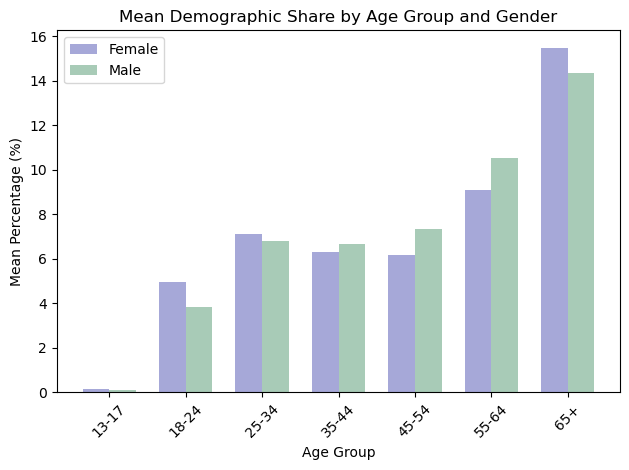

In [42]:
# Compute mean share by age_group and gender
mean_demo = (demo_df_valid.groupby(['age_group', 'gender'], as_index=False).agg({'value': 'mean'}))

# Pivot for grouped bar plotting
pivot_demo = mean_demo.pivot(index='age_group', columns='gender', values='value')

import matplotlib.pyplot as plt
import numpy as np

# Ensure consistent age order (sorted naturally)
pivot_demo = pivot_demo.sort_index()

x = np.arange(len(pivot_demo.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, pivot_demo['female'], width, label='Female', color='#a6a8d8')
plt.bar(x + width/2, pivot_demo['male'], width, label='Male', color='#a8cbb7')

plt.xticks(x, pivot_demo.index, rotation=45)
plt.xlabel('Age Group')
plt.ylabel('Mean Percentage (%)')
plt.title('Mean Demographic Share by Age Group and Gender')
plt.legend()

plt.tight_layout()
plt.show()

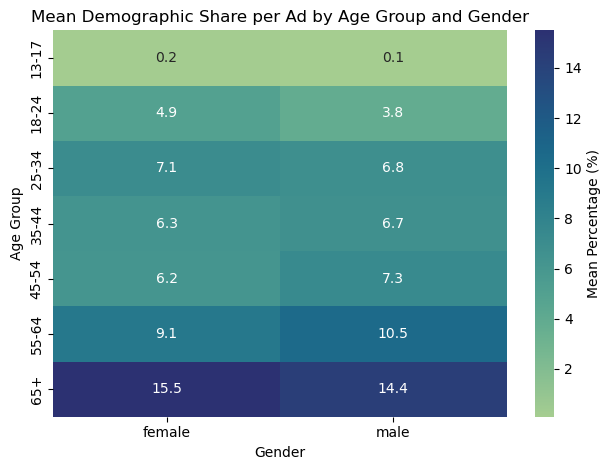

In [45]:
mean_demo_by_age_gender = (demo_df_valid.groupby(['age_group','gender'])['value'].mean().unstack())
mean_demo_by_age_gender = mean_demo_by_age_gender.drop(columns=['unknown'])

ax = sns.heatmap(
    mean_demo_by_age_gender,
    annot=True,
    fmt=".1f",
    cmap="crest"
)

ax.set_title("Mean Demographic Share per Ad by Age Group and Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Age Group")

cbar = ax.collections[0].colorbar
cbar.set_label("Mean Percentage (%)")

plt.tight_layout()
plt.show()

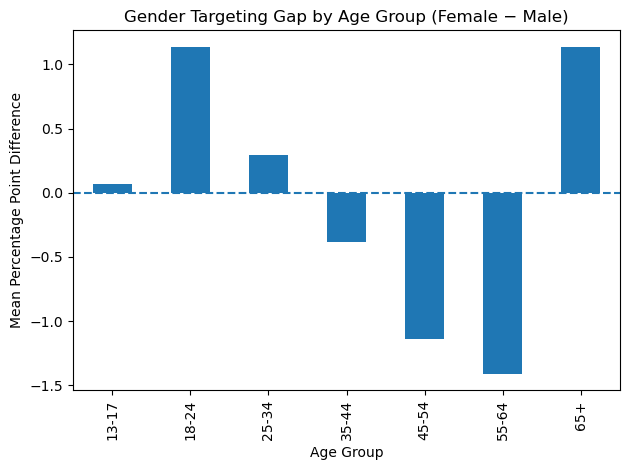

In [38]:
gap = mean_demo_by_age_gender['female'] - mean_demo_by_age_gender['male']

gap.plot(kind='bar')

plt.axhline(0, linestyle='--')
plt.title("Gender Targeting Gap by Age Group (Female − Male)")
plt.ylabel("Mean Percentage Point Difference")
plt.xlabel("Age Group")

plt.tight_layout()
plt.show()

In [47]:
# TIME SERIES ANALYSIS

In [48]:
df.columns

Index(['id', 'ad_creation_time', 'ad_delivery_start_time', 'bylines',
       'currency', 'page_id', 'page_name', 'ad_creative_bodies',
       'ad_creative_link_captions', 'ad_creative_link_descriptions',
       'ad_creative_link_titles', 'audience_size_lower', 'impressions_lower',
       'impressions_upper', 'spend_lower', 'spend_upper', 'ad_snapshot_url',
       'language_en', 'language_es', 'language_other', 'platform_fb',
       'platform_ig', 'platform_other', '13-17/female', '13-17/male',
       '13-17/unknown', '18-24/female', '18-24/male', '18-24/unknown',
       '25-34/female', '25-34/male', '25-34/unknown', '35-44/female',
       '35-44/male', '35-44/unknown', '45-54/female', '45-54/male',
       '45-54/unknown', '55-64/female', '55-64/male', '55-64/unknown',
       '65+/female', '65+/male', '65+/unknown', 'Unknown/female',
       'Unknown/male', 'Unknown/unknown'],
      dtype='object')

In [49]:
time_df = df.copy()
time_df['ad_delivery_start_time'] = pd.to_datetime(time_df['ad_delivery_start_time'])

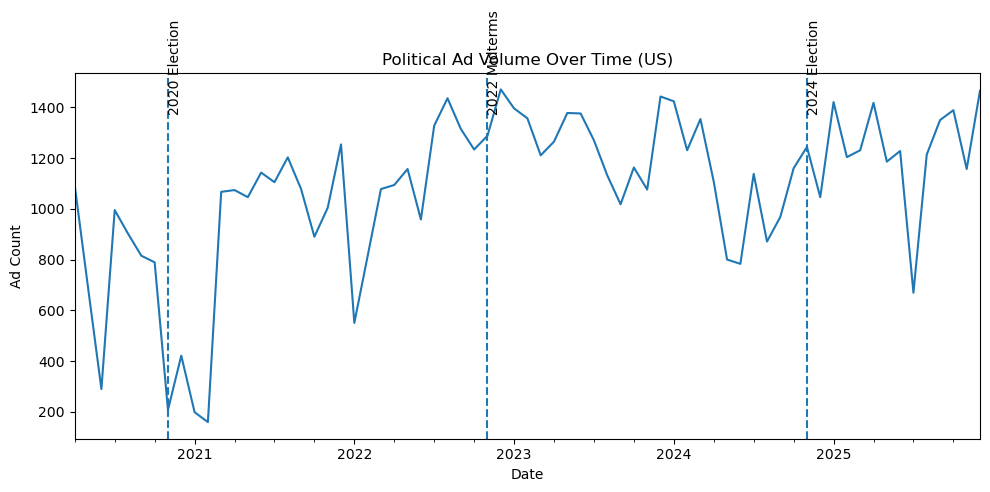

In [57]:
#1
time_df['year_month'] = time_df['ad_delivery_start_time'].dt.to_period('M')

ads_over_time = (
    time_df
    .groupby('year_month')
    .size()
)

ads_over_time.index = ads_over_time.index.to_timestamp()
important_dates = [
    ('2020-11-03', '2020 Election'),
    ('2022-11-08', '2022 Midterms'),
    ('2024-11-05', '2024 Election')
]

plt.figure(figsize=(10,5))
ads_over_time.plot()

for date, label in important_dates:
    plt.axvline(pd.to_datetime(date), linestyle='--')
    plt.text(pd.to_datetime(date), 
             plt.ylim()[1]*0.9, 
             label, 
             rotation=90)

plt.title("Political Ad Volume Over Time (US)")
plt.ylabel("Ad Count")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

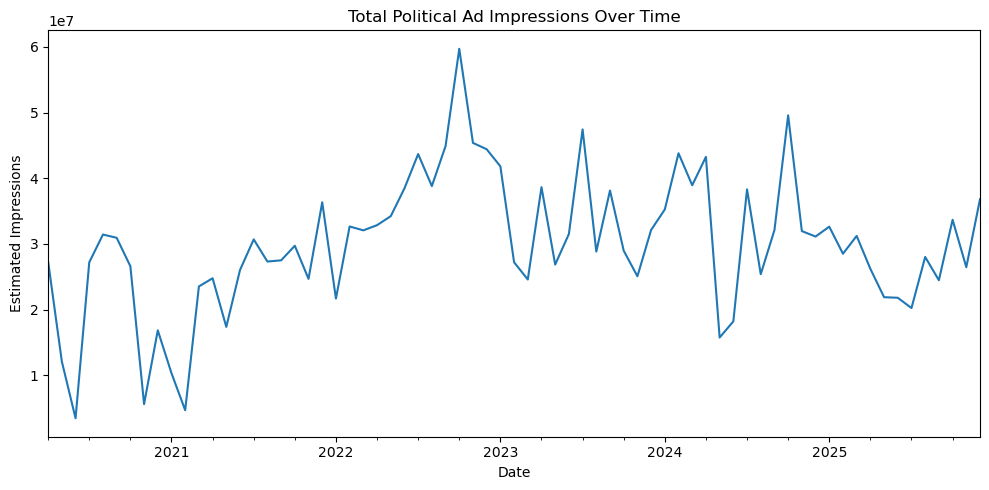

In [ ]:
#2

time_df['impressions_mid'] = (
    time_df['impressions_lower'] + time_df['impressions_upper']
) / 2

impressions_over_time = (
    df
    .groupby('year_month')['impressions_mid']
    .sum()
)

impressions_over_time.index = impressions_over_time.index.to_timestamp()

plt.figure(figsize=(10,5))
impressions_over_time.plot()
plt.title("Total Political Ad Impressions Over Time")
plt.ylabel("Estimated Impressions")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

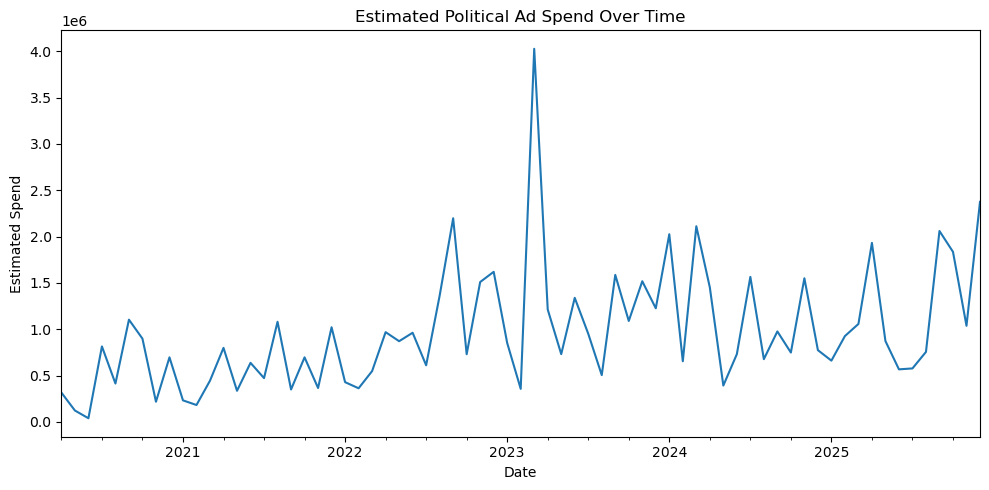

In [56]:
#3

time_df['spend_mid'] = (
    time_df['spend_lower'] + time_df['spend_upper']
) / 2

spend_over_time = (
    time_df
    .groupby('year_month')['spend_mid']
    .sum()
)

spend_over_time.index = spend_over_time.index.to_timestamp()

plt.figure(figsize=(10,5))
spend_over_time.plot()
plt.title("Estimated Political Ad Spend Over Time")
plt.ylabel("Estimated Spend")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [ ]:
# top spending pages in the spike month of March 2023, which is the month with the highest ad spend in the dataset
df_2023 = time_df[time_df['ad_delivery_start_time'].dt.year == 2023]
top_spike_month = df_2023[df_2023['year_month'] == '2023-03']
top_spike_month.groupby('page_name')['spend_mid'].sum().sort_values(ascending=False).head(10)

page_name
The True Patriots                         949999.5
The Patriot Movement                      849999.5
Walden University                         769996.5
Proud American Patriots                   649999.5
Angela Romero - La Revolución del Amor    252646.5
Metaverse platform - cluster               94999.5
Kristian Thomas for DPRD DKI 2024          94999.5
Everytown for Gun Safety                   89998.0
NEA Today                                  23698.5
SEIU                                       18996.5
Name: spend_mid, dtype: float64

In [78]:
# FINDING BUZZWORDS

In [86]:
df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,55-64/female,55-64/male,55-64/unknown,65+/female,65+/male,65+/unknown,Unknown/female,Unknown/male,Unknown/unknown,clean_text
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.97,1.22,0.01,0.94,0.80,0.01,0.0,0.0,0.0,cancel culture is killing intellectual convers...
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,2.56,5.44,0.06,3.05,3.22,0.04,0.0,0.0,0.0,on this week's episode we are joined by bret s...
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,19.13,19.85,0.25,20.26,12.40,0.25,0.0,0.0,0.0,straight facts to see through the hysteria.we ...
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,19.72,19.94,0.25,18.27,10.68,0.25,0.0,0.0,0.0,straight facts to see through the hysteria.we ...
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,18.72,21.20,0.28,14.66,10.20,0.22,0.0,0.0,0.0,straight facts to see through the hysteria.we ...


In [88]:
buzz_df = df.copy()

buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]

buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

demo_cols = [col for col in buzz_df.columns if '/' in col]
demo_cols = [col for col in demo_cols if not col.startswith('Unknown/')]

age_ranges = sorted(set(col.split('/')[0] for col in demo_cols))
genders = sorted(set(col.split('/')[1] for col in demo_cols))

# age totals
for age in age_ranges:
    age_specific_cols = [col for col in demo_cols if col.startswith(age + '/')]
    buzz_df[f'age_{age}_total'] = buzz_df[age_specific_cols].sum(axis=1)

age_total_cols = [f'age_{age}_total' for age in age_ranges]

# gender totals
for gender in genders:
    gender_specific_cols = [col for col in demo_cols if col.endswith('/' + gender)]
    buzz_df[f'gender_{gender}_total'] = buzz_df[gender_specific_cols].sum(axis=1)

gender_total_cols = [f'gender_{gender}_total' for gender in genders]

# original gender + age totals
age_gender_cols = demo_cols.copy()

buzz_df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,age_13-17_total,age_18-24_total,age_25-34_total,age_35-44_total,age_45-54_total,age_55-64_total,age_65+_total,gender_female_total,gender_male_total,gender_unknown_total
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.0,54.17,33.49,5.78,2.62,2.20,1.75,57.79,41.85,0.37
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,0.0,44.80,31.17,5.07,4.60,8.06,6.31,51.23,48.40,0.38
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.35,1.29,5.28,20.94,39.23,32.91,48.63,50.71,0.66
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.34,1.41,6.05,23.08,39.91,29.20,48.17,51.18,0.64
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.35,1.58,7.43,25.35,40.20,25.08,43.19,56.14,0.66


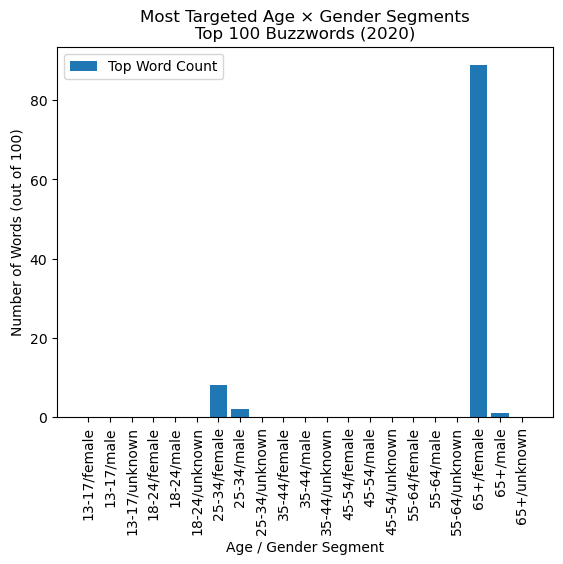

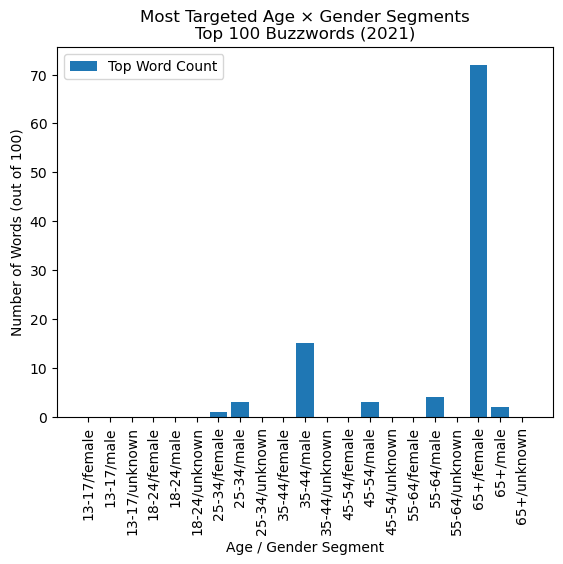

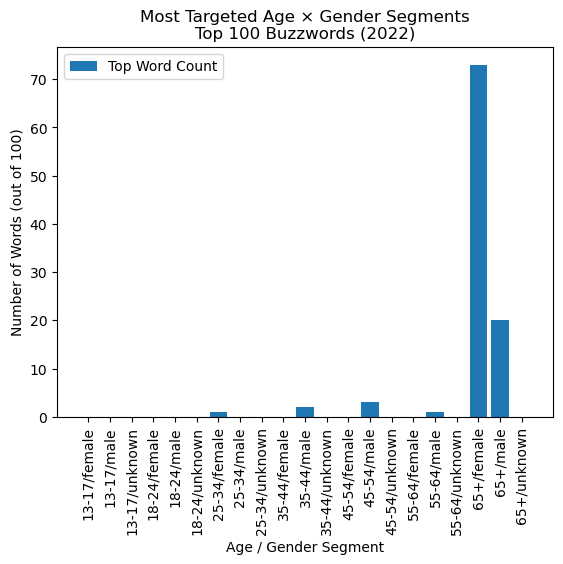

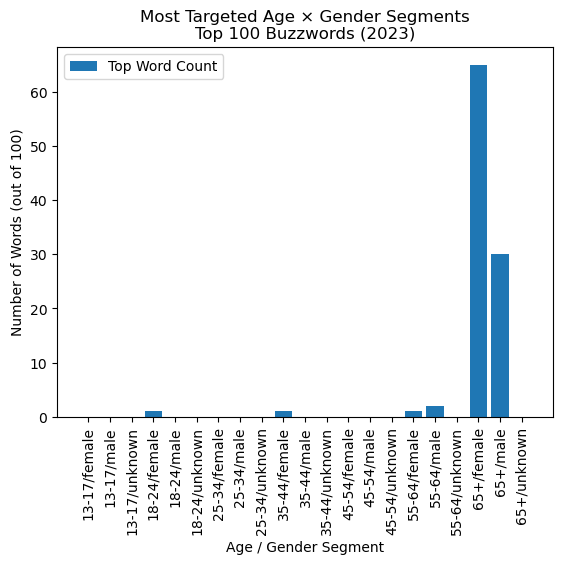

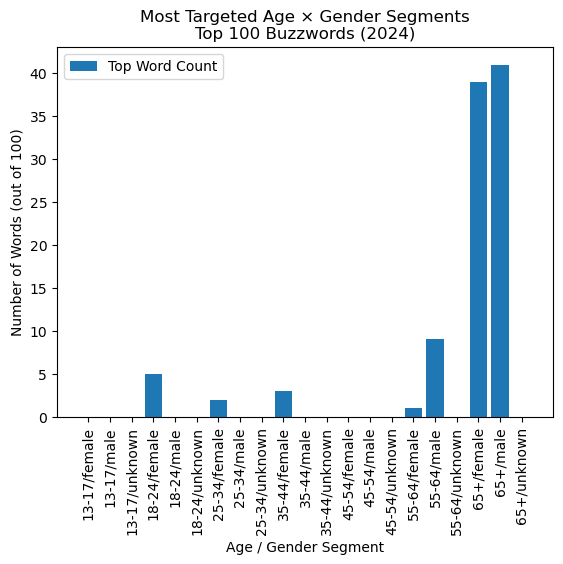

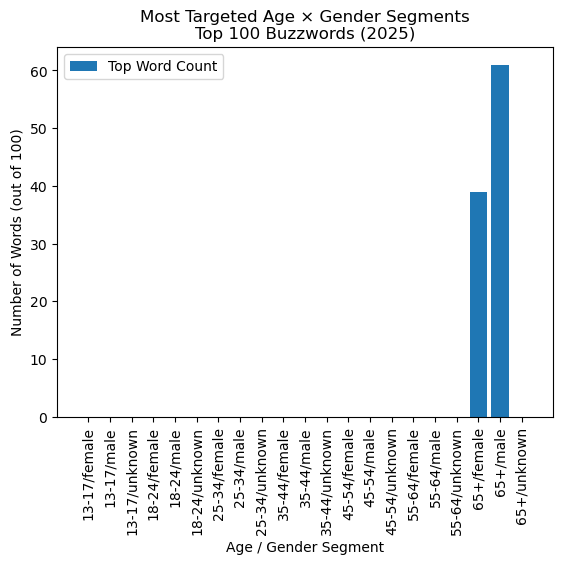

In [ ]:
years = sorted(buzz_df['year'].unique())

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    
    if len(year_df) < 50:
        continue
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        min_df=5,
        ngram_range=(1,1)
    )
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    tfidf_means = np.asarray(X.mean(axis=0)).flatten()
    top_indices = tfidf_means.argsort()[-100:][::-1]
    top_words = feature_names[top_indices]
    
    # Age × Gender Targeting Count
    
    segment_counts = {col: 0 for col in age_gender_cols}
    
    for word in top_words:
        
        word_idx = np.where(feature_names == word)[0][0]
        word_mask = X[:, word_idx].toarray().flatten() > 0
        
        if word_mask.sum() == 0:
            continue
        
        subset = year_df.loc[word_mask, age_gender_cols]
        avg_target = subset.mean()
        
        top_segment = avg_target.idxmax()
        segment_counts[top_segment] += 1
    
    plt.figure()
    
    segments = list(segment_counts.keys())
    counts = list(segment_counts.values())
    
    plt.bar(segments, counts, label='Top Word Count')
    
    plt.title(f'Most Targeted Age × Gender Segments\nTop 100 Buzzwords ({year})')
    plt.xlabel('Age / Gender Segment')
    plt.ylabel('Number of Words (out of 100)')
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

buzz_df = buzz_df.copy()
buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]
buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

years = sorted(buzz_df['year'].unique())

top_words_by_year = {}

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    
    if len(year_df) < 50:
        continue
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        min_df=5,
        ngram_range=(1,1)
    )
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    tfidf_means = np.asarray(X.mean(axis=0)).flatten()
    top_indices = tfidf_means.argsort()[-100:][::-1]
    top_words = feature_names[top_indices]
    
    top_words_by_year[year] = set(top_words)

In [95]:
for year, words in top_words_by_year.items():
    print(f"\nTop 100 Buzzwords for {year}:\n")
    print(sorted(list(words)))


Top 100 Buzzwords for 2020:

['000', '10', '19', '2020', 'account', 'ad', 'advertising', 'america', 'americans', 'ballot', 'biden', 'black', 'campaign', 'care', 'change', 'click', 'com', 'community', 'congress', 'country', 'covid', 'day', 'democrats', 'disabled', 'disclaimer', 'don', 'donate', 'election', 'ensure', 'fair', 'families', 'fight', 'following', 'free', 'georgia', 'great', 'help', 'hey', 'https', 'information', 'joe', 'join', 'just', 'know', 'later', 'learn', 'let', 'like', 'mail', 'make', 'national', 'need', 'new', 'news', 'november', 'office', 'open', 'org', 'page', 'people', 'petition', 'political', 'power', 'president', 'protect', 'public', 'quiz', 'ran', 'register', 'request', 'required', 'right', 'run', 'safe', 'save', 'sees', 'senate', 'share', 'shirt', 'sign', 'stand', 'standards', 'state', 'states', 'stop', 'support', 'sure', 'tax', 'think', 'time', 'today', 'trump', 'use', 'vote', 'voter', 'voting', 'want', 'world', 'www', 'yes']

Top 100 Buzzwords for 2021:

['20

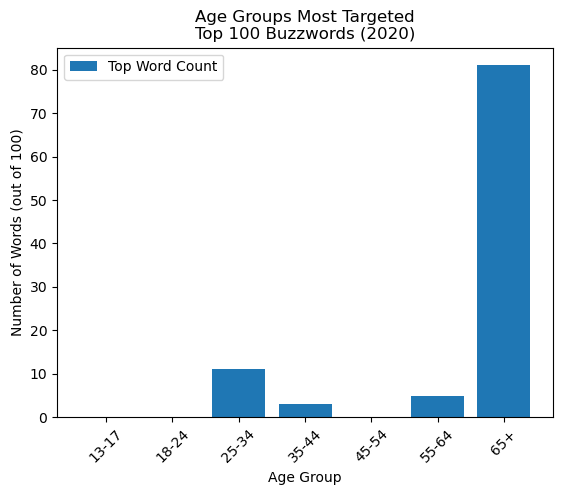

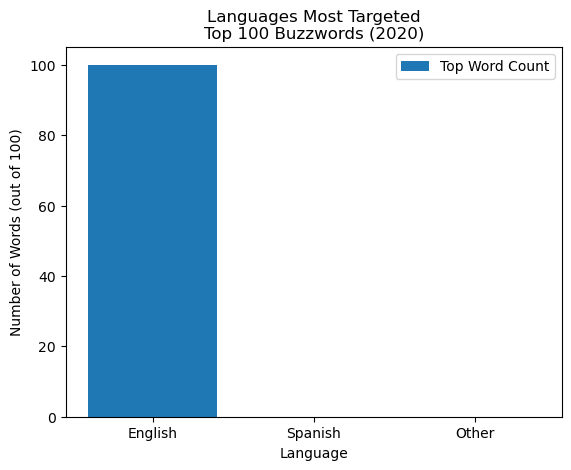

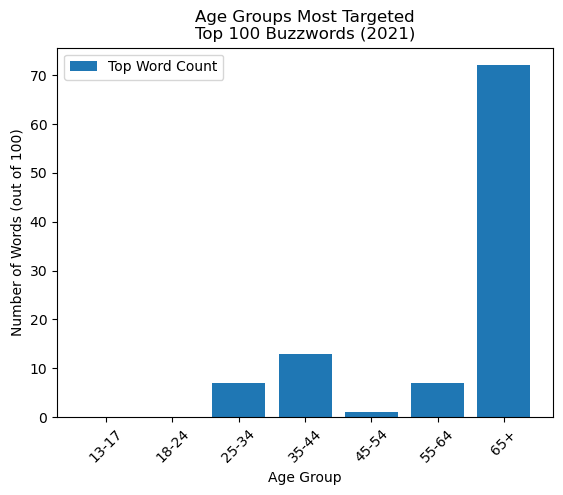

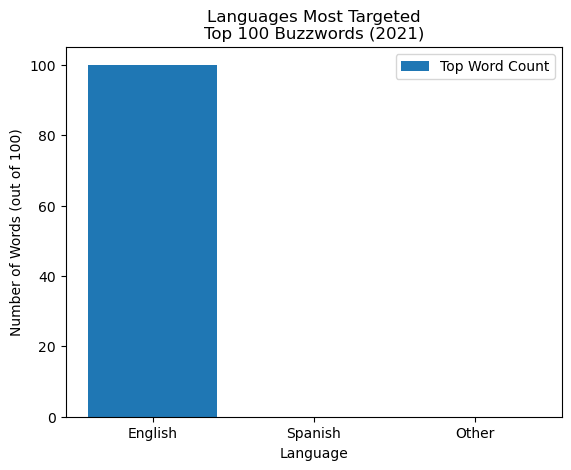

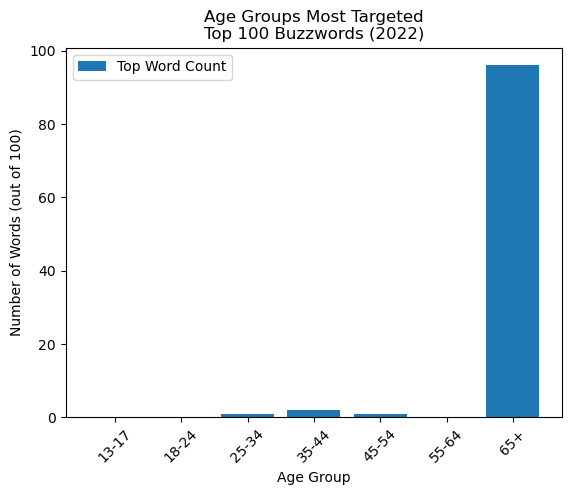

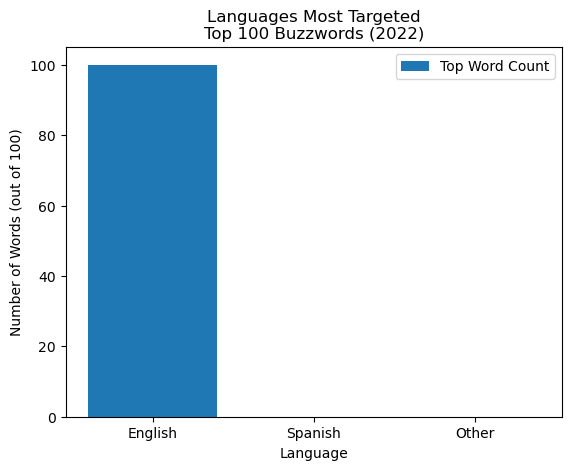

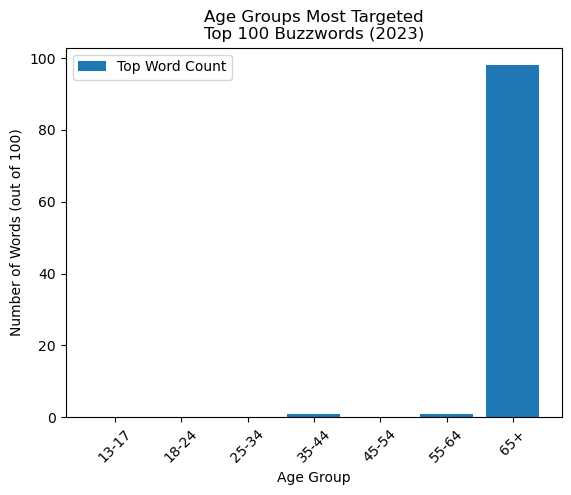

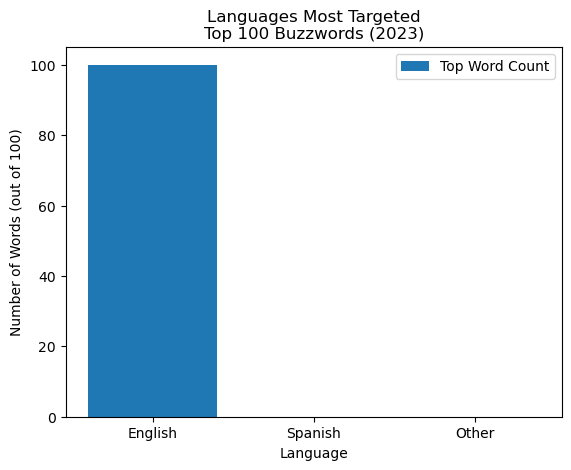

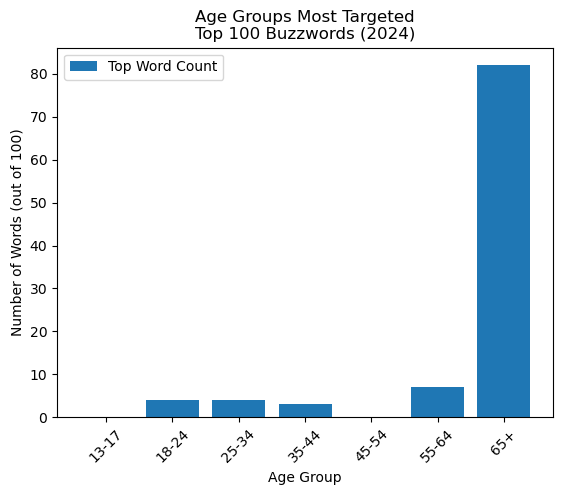

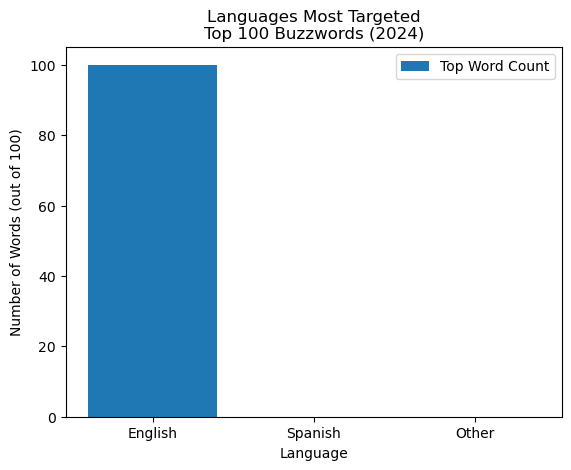

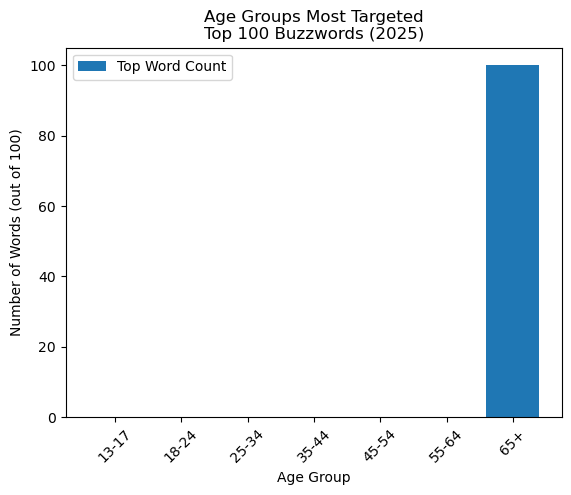

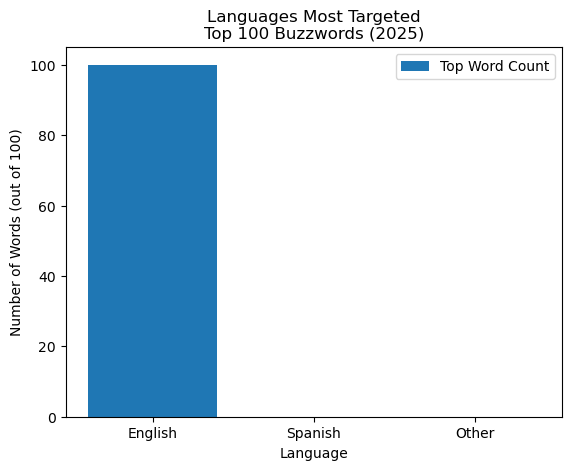

In [104]:
age_cols = [col for col in buzz_df.columns 
            if col.startswith('age_') and col.endswith('_total')]
language_cols = ['language_en', 'language_es', 'language_other']

years = sorted(top_words_by_year.keys())

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    top_words = top_words_by_year[year]
    
    # Recompute TFIDF for mask indexing
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        min_df=5
    )
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    #age targeting counts
    
    age_counts = {col.replace('age_','').replace('_total',''): 0 
                  for col in age_cols}
    
    language_counts = {'English':0, 'Spanish':0, 'Other':0}
    
    for word in top_words:
        
        if word not in feature_names:
            continue
        
        word_idx = np.where(feature_names == word)[0][0]
        word_mask = X[:, word_idx].toarray().flatten() > 0
        
        if word_mask.sum() == 0:
            continue
        
        subset = year_df.loc[word_mask]
        
        # age
        avg_age = subset[age_cols].mean()
        top_age = avg_age.idxmax()
        top_age_clean = top_age.replace('age_','').replace('_total','')
        age_counts[top_age_clean] += 1
        
        # language
        avg_lang = subset[language_cols].mean()
        top_lang = avg_lang.idxmax()
        
        if top_lang == 'language_en':
            language_counts['English'] += 1
        elif top_lang == 'language_es':
            language_counts['Spanish'] += 1
        else:
            language_counts['Other'] += 1
    
# plot age targeting result
    
    plt.figure()
    plt.bar(age_counts.keys(), age_counts.values(), label='Top Word Count')
    plt.title(f'Age Groups Most Targeted\nTop 100 Buzzwords ({year})')
    plt.xlabel('Age Group')
    plt.ylabel('Number of Words (out of 100)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()
    

#plot language result
    
    plt.figure()
    plt.bar(language_counts.keys(), language_counts.values(), label='Top Word Count')
    plt.title(f'Languages Most Targeted\nTop 100 Buzzwords ({year})')
    plt.xlabel('Language')
    plt.ylabel('Number of Words (out of 100)')
    plt.legend()
    plt.show()

In [96]:
years_list = list(top_words_by_year.keys())

overlap_matrix = pd.DataFrame(
    index=years_list,
    columns=years_list
)

for y1 in years_list:
    for y2 in years_list:
        
        intersection = top_words_by_year[y1].intersection(top_words_by_year[y2])
        overlap_matrix.loc[y1, y2] = len(intersection)

overlap_matrix = overlap_matrix.astype(int)

print("\nOverlap Matrix (Raw Counts):\n")
print(overlap_matrix)


Overlap Matrix (Raw Counts):

      2020  2021  2022  2023  2024  2025
2020   100    60    65    62    50    51
2021    60   100    79    66    53    54
2022    65    79   100    73    59    60
2023    62    66    73   100    61    61
2024    50    53    59    61   100    67
2025    51    54    60    61    67   100


In [97]:
percent_overlap_matrix = overlap_matrix / 100 * 100  # since top 100
print("\nOverlap Matrix (Percentage):\n")
print(percent_overlap_matrix)


Overlap Matrix (Percentage):

       2020   2021   2022   2023   2024   2025
2020  100.0   60.0   65.0   62.0   50.0   51.0
2021   60.0  100.0   79.0   66.0   53.0   54.0
2022   65.0   79.0  100.0   73.0   59.0   60.0
2023   62.0   66.0   73.0  100.0   61.0   61.0
2024   50.0   53.0   59.0   61.0  100.0   67.0
2025   51.0   54.0   60.0   61.0   67.0  100.0


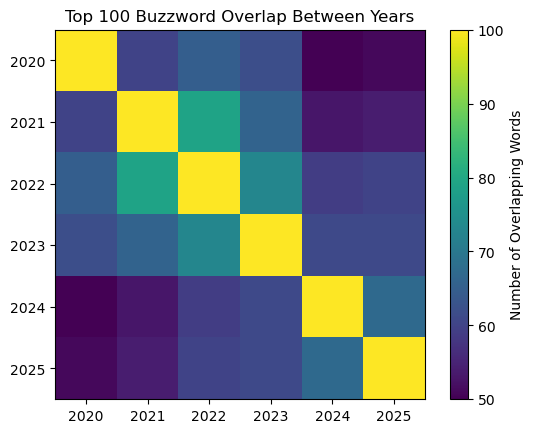

In [98]:
plt.figure()

plt.imshow(overlap_matrix.values)
plt.xticks(range(len(years_list)), years_list)
plt.yticks(range(len(years_list)), years_list)
plt.title("Top 100 Buzzword Overlap Between Years")
plt.colorbar(label='Number of Overlapping Words')

plt.show()

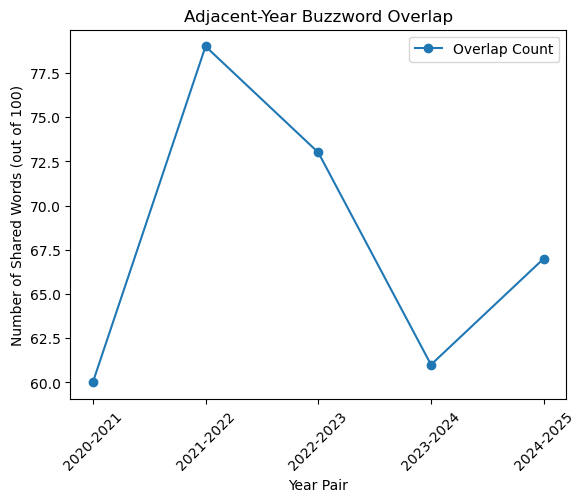

In [99]:
adjacent_overlap = {}

for i in range(len(years_list)-1):
    y1 = years_list[i]
    y2 = years_list[i+1]
    
    overlap = len(top_words_by_year[y1] & top_words_by_year[y2])
    adjacent_overlap[f"{y1}-{y2}"] = overlap

plt.figure()
plt.plot(list(adjacent_overlap.keys()),
         list(adjacent_overlap.values()),
         marker='o',
         label='Overlap Count')

plt.title('Adjacent-Year Buzzword Overlap')
plt.xlabel('Year Pair')
plt.ylabel('Number of Shared Words (out of 100)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

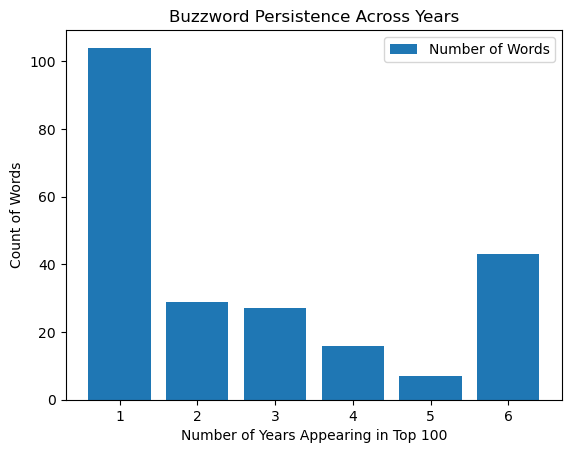

In [100]:
from collections import Counter

all_words = []

for words in top_words_by_year.values():
    all_words.extend(list(words))

word_counts = Counter(all_words)

survival_counts = Counter(word_counts.values())

plt.figure()
plt.bar(survival_counts.keys(),
        survival_counts.values(),
        label='Number of Words')

plt.title('Buzzword Persistence Across Years')
plt.xlabel('Number of Years Appearing in Top 100')
plt.ylabel('Count of Words')
plt.legend()
plt.show()

In [ ]:
# FREQUENCY OF ADS BY LANGUAGE CATEGORY

In [65]:
df[['language_en','language_es','language_other']].head()

,language_en,language_es,language_other
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [67]:
language_counts = {
    'English': df['language_en'].sum(),
    'Spanish': df['language_es'].sum(),
    'Other': df['language_other'].sum()
}

language_counts

{'English': np.int64(68214), 'Spanish': np.int64(1631), 'Other': np.int64(680)}

In [68]:
df[['language_en','language_es','language_other']].sum(axis=1).value_counts()

1    70471
0     3788
2       24
3        2
Name: count, dtype: int64

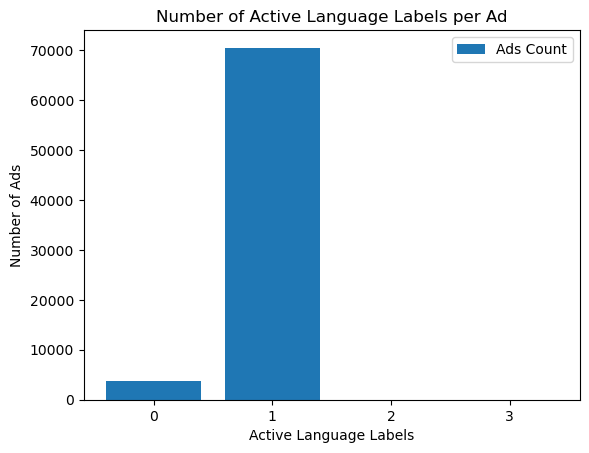

In [ ]:
# number of active language labels per ad
lang_cols = ['language_en', 'language_es', 'language_other']
row_sums = df[lang_cols].sum(axis=1)
consistency_counts = row_sums.value_counts().sort_index()

plt.figure()
plt.bar(consistency_counts.index.astype(str), consistency_counts.values, label='Ads Count')
plt.title('Number of Active Language Labels per Ad')
plt.xlabel('Active Language Labels')
plt.ylabel('Number of Ads')
plt.legend()
plt.show()

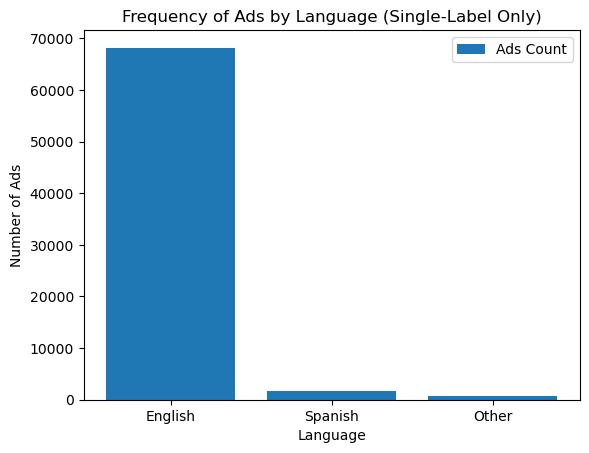

In [ ]:
# language vs. frequency (single-label only)
= df[row_sums == 1]
clean_counts = clean_df[lang_cols].sum()

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], clean_counts.values, label='Ads Count')
plt.title('Frequency of Ads by Language (Single-Label Only)')
plt.xlabel('Language')
plt.ylabel('Number of Ads')
plt.legend()
plt.show()

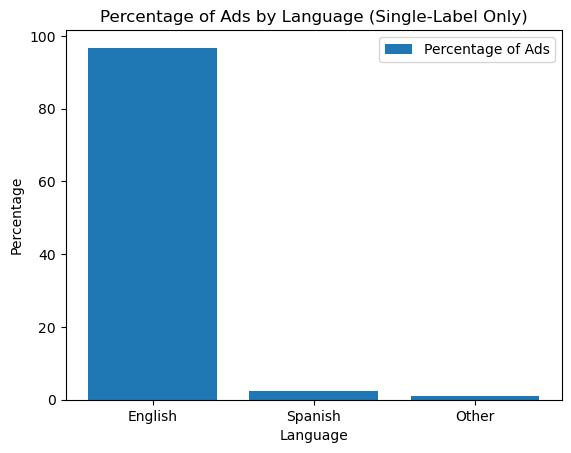

In [ ]:
# language vs. percentage of ads
clean_percent = clean_counts / clean_counts.sum() * 100

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], clean_percent.values, label='Percentage of Ads')
plt.title('Percentage of Ads by Language (Single-Label Only)')
plt.xlabel('Language')
plt.ylabel('Percentage')
plt.legend()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_35188\3396903469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['spend_avg'] = (clean_df['spend_lower'] + clean_df['spend_upper']) / 2


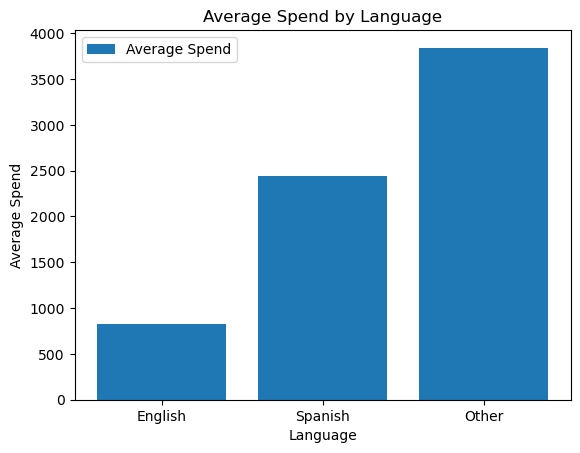

In [ ]:
# language vs. average spend
clean_df['spend_avg'] = (clean_df['spend_lower'] + clean_df['spend_upper']) / 2

avg_spend = [
    clean_df[clean_df['language_en']]['spend_avg'].mean(),
    clean_df[clean_df['language_es']]['spend_avg'].mean(),
    clean_df[clean_df['language_other']]['spend_avg'].mean()
]

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], avg_spend, label='Average Spend')
plt.title('Average Spend by Language')
plt.xlabel('Language')
plt.ylabel('Average Spend')
plt.legend()
plt.show()

C:\Users\clair\AppData\Local\Temp\ipykernel_35188\1406649419.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['impressions_avg'] = (clean_df['impressions_lower'] + clean_df['impressions_upper']) / 2


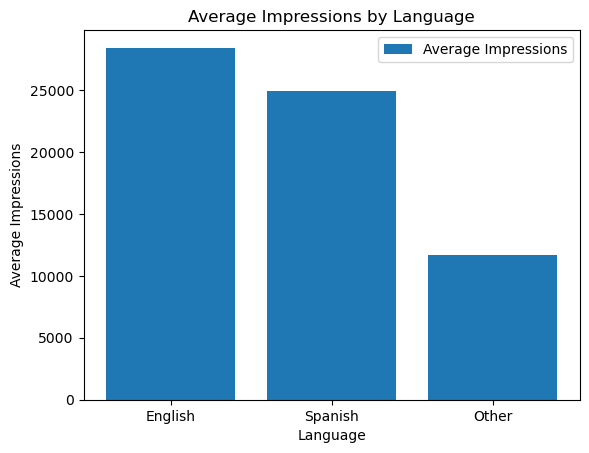

In [ ]:
# language vs. average impressions
clean_df['impressions_avg'] = (clean_df['impressions_lower'] + clean_df['impressions_upper']) / 2

avg_impressions = [
    clean_df[clean_df['language_en']]['impressions_avg'].mean(),
    clean_df[clean_df['language_es']]['impressions_avg'].mean(),
    clean_df[clean_df['language_other']]['impressions_avg'].mean()
]

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], avg_impressions, label='Average Impressions')
plt.title('Average Impressions by Language')
plt.xlabel('Language')
plt.ylabel('Average Impressions')
plt.legend()
plt.show()

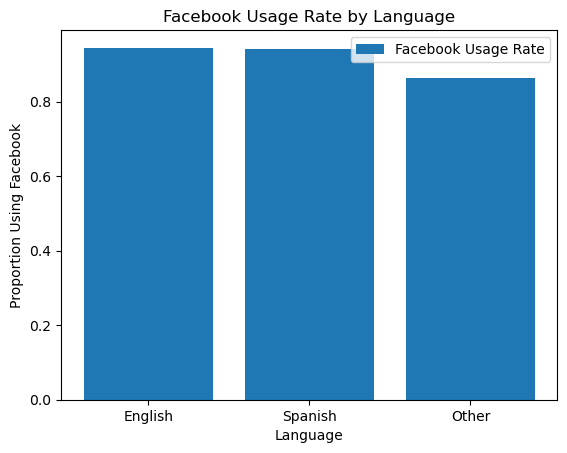

In [80]:
# language vs. platform usage (Facebook vs Instagram)
platform_usage = [
    clean_df[clean_df['language_en']]['platform_fb'].mean(),
    clean_df[clean_df['language_es']]['platform_fb'].mean(),
    clean_df[clean_df['language_other']]['platform_fb'].mean()
]

plt.figure()
plt.bar(['English', 'Spanish', 'Other'], platform_usage, label='Facebook Usage Rate')
plt.title('Facebook Usage Rate by Language')
plt.xlabel('Language')
plt.ylabel('Proportion Using Facebook')
plt.legend()
plt.show()

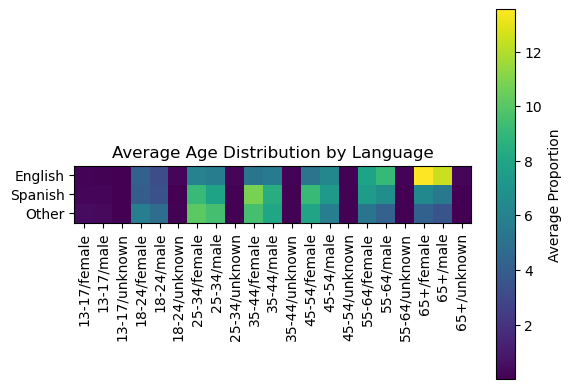

In [81]:
# language vs. age distribution
age_cols = [col for col in df.columns if '/' in col and col.split('/')[0] != 'Unknown']

age_distribution = []
for lang in lang_cols:
    subset = clean_df[clean_df[lang]]
    age_distribution.append(subset[age_cols].mean().values)

age_distribution = np.array(age_distribution)

plt.figure()
plt.imshow(age_distribution)
plt.xticks(range(len(age_cols)), age_cols, rotation=90)
plt.yticks(range(3), ['English', 'Spanish', 'Other'])
plt.title('Average Age Distribution by Language')
plt.colorbar(label='Average Proportion')
plt.show()